# Analiza zbioru [ESC-50](https://github.com/karolpiczak/ESC-50)

In [1]:
import pandas as pd
from pyprojroot import here
import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio, Markdown

In [2]:
ROOT = here()
AUDIO_DIR = ROOT / "ESC-50" / "audio"
METADATA_PATH = ROOT / "ESC-50" / "meta" / "esc50.csv"

OUTPUT_DIR = ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
meta = pd.read_csv(METADATA_PATH)
display(Markdown(f"Metadata shape: **{meta.shape}**"))

del meta["esc10"]
display(meta.head())

Metadata shape: **(2000, 7)**

,filename,fold,target,category,src_file,take
0,1-100032-A-0.wav,1,0,dog,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,101296,A


In [4]:
categories = np.unique(meta["category"])
counts = meta["category"].value_counts().tolist()

display(Markdown(f"### Kategorie ({len(categories)}):"))

print(meta[['target', 'category']].drop_duplicates().sort_values('target').to_string(index=False))

### Kategorie (50):

 target         category
      0              dog
      1          rooster
      2              pig
      3              cow
      4             frog
      5              cat
      6              hen
      7          insects
      8            sheep
      9             crow
     10             rain
     11        sea_waves
     12   crackling_fire
     13         crickets
     14   chirping_birds
     15      water_drops
     16             wind
     17    pouring_water
     18     toilet_flush
     19     thunderstorm
     20      crying_baby
     21         sneezing
     22         clapping
     23        breathing
     24         coughing
     25        footsteps
     26         laughing
     27   brushing_teeth
     28          snoring
     29 drinking_sipping
     30  door_wood_knock
     31      mouse_click
     32  keyboard_typing
     33 door_wood_creaks
     34      can_opening
     35  washing_machine
     36   vacuum_cleaner
     37      clock_alarm
     38       clock_tick


In [5]:
display(meta['fold'].value_counts().to_frame().T)

fold,1,2,3,4,5
count,400,400,400,400,400


In [6]:
selected_categories = ["dog", "rain", "thunderstorm", "clock_tick", "engine"]
examples = {}
for cat in selected_categories:
    example_row = meta[meta['category'] == cat].iloc[0]
    examples[cat] = example_row['filename']

    display(Markdown(f"### Przykładowy dźwięk: {cat}"))
    display(Audio(AUDIO_DIR / example_row['filename']))

### Przykładowy dźwięk: dog

### Przykładowy dźwięk: rain

### Przykładowy dźwięk: thunderstorm

### Przykładowy dźwięk: clock_tick

### Przykładowy dźwięk: engine

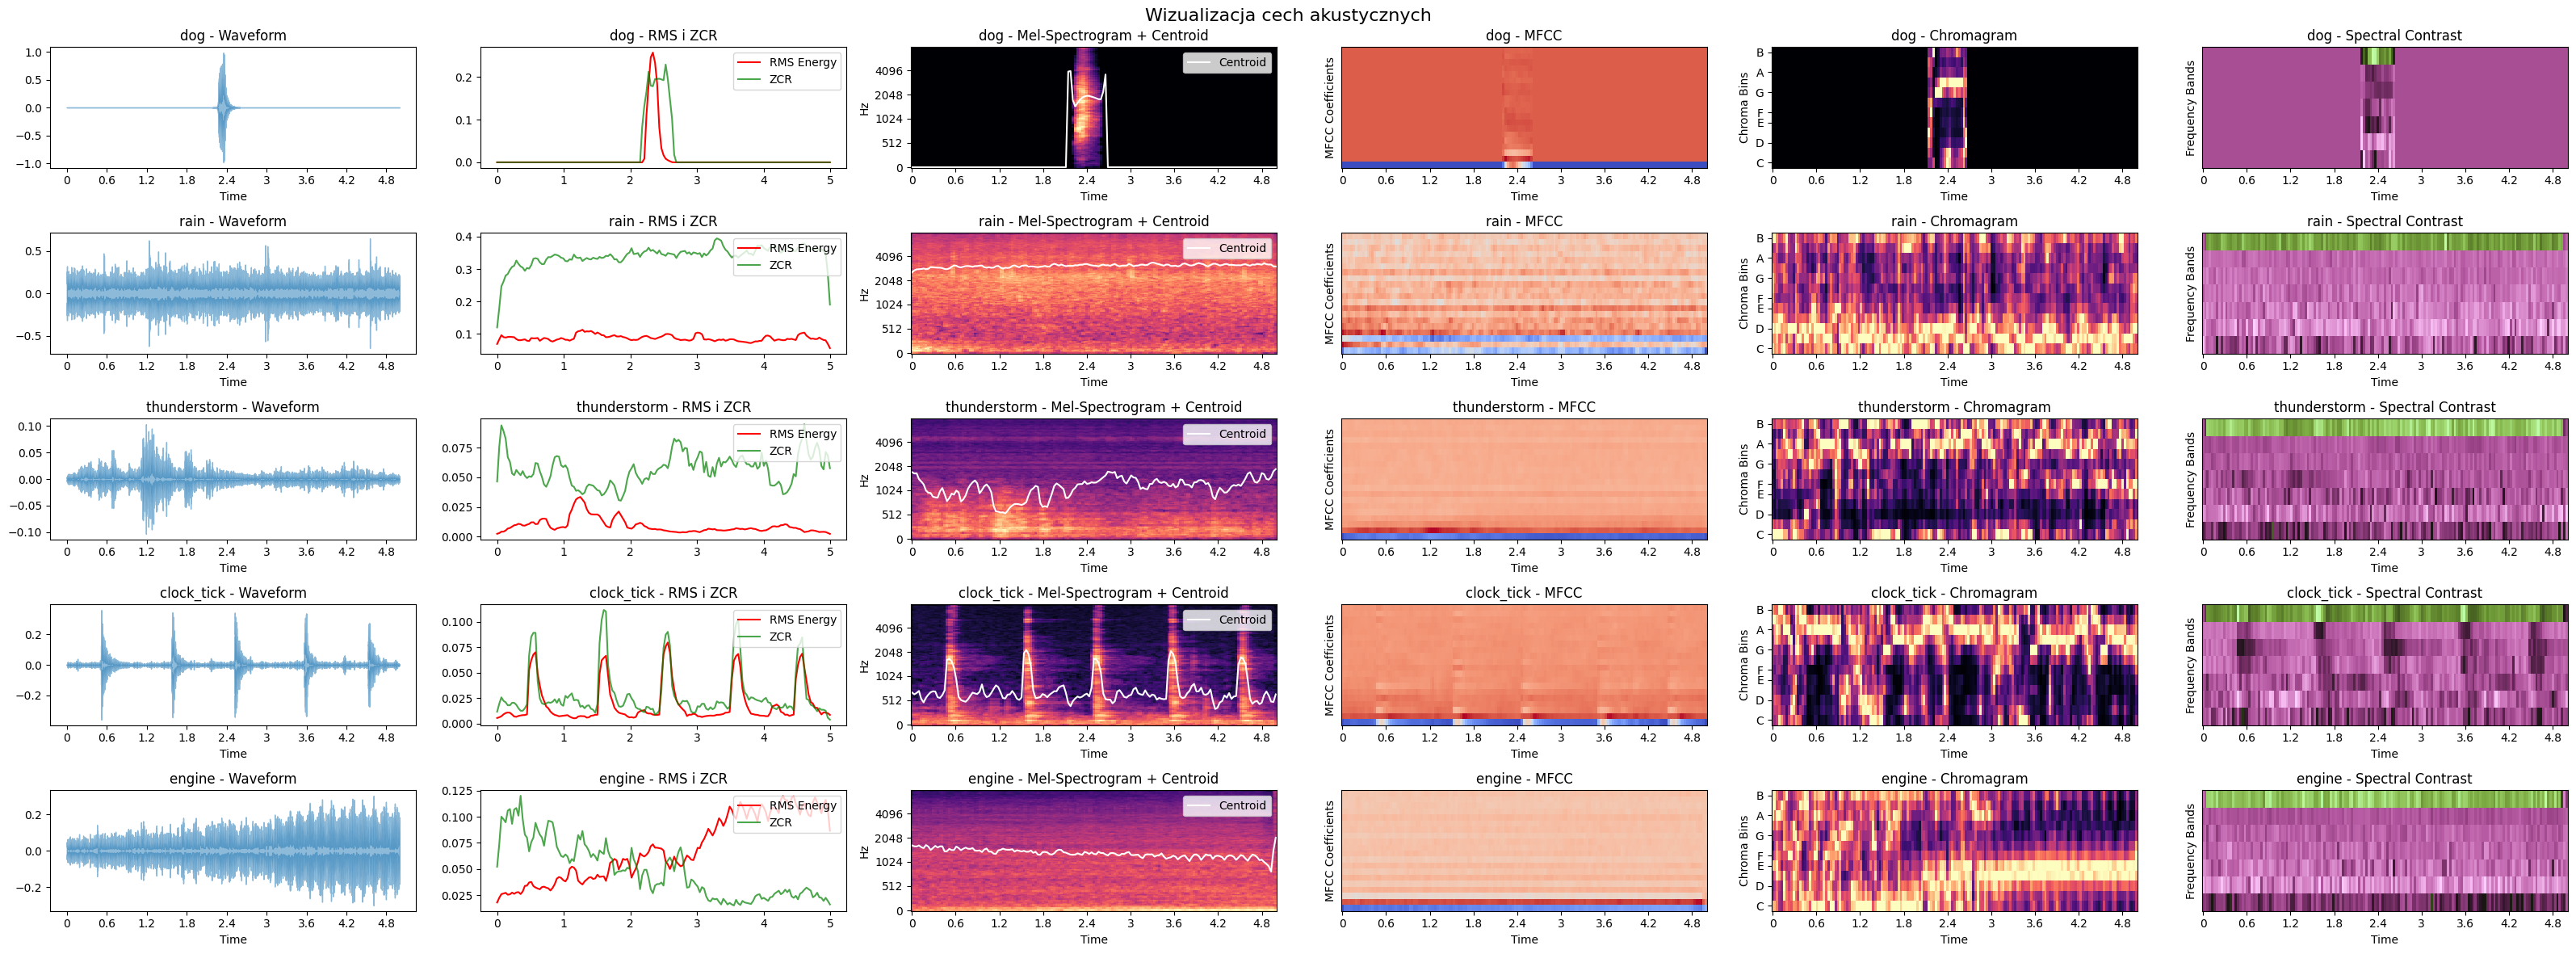

In [7]:
sr = 16000

fig, axes = plt.subplots(len(examples), 6, figsize=(32, 12))

for i, (label, fname) in enumerate(examples.items()):
    y, sr = librosa.load(AUDIO_DIR / fname, sr=sr)
    
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], alpha=0.5)
    axes[i, 0].set_title(f"{label} - Waveform")
    
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    times = librosa.times_like(rms, sr=sr)
    
    axes[i, 1].plot(times, rms, label='RMS Energy', color='r')
    axes[i, 1].plot(times, zcr, label='ZCR', color='g', alpha=0.7)
    axes[i, 1].set_title(f"{label} - RMS i ZCR")
    axes[i, 1].legend(loc='upper right')
    
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 2])

    cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    axes[i, 2].plot(times, cent, color='w', label='Centroid', linewidth=1.5)
    axes[i, 2].set_title(f"{label} - Mel-Spectrogram + Centroid")
    axes[i, 2].legend(loc='upper right')
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[i, 3])
    axes[i, 3].set_title(f"{label} - MFCC")
    axes[i, 3].set_ylabel('MFCC Coefficients')

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=axes[i, 4])
    axes[i, 4].set_title(f"{label} - Chromagram")
    axes[i, 4].set_ylabel('Chroma Bins')

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    librosa.display.specshow(contrast, sr=sr, x_axis='time', ax=axes[i, 5], cmap='vanimo')
    axes[i, 5].set_ylabel('Frequency Bands')
    axes[i, 5].set_title(f"{label} - Spectral Contrast")

fig.suptitle("Wizualizacja cech akustycznych", fontsize=16)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_visualizations.png")
plt.show()